# Эксперементы с Leaf Model

Датасет №2

In [1]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("fridrichmrtn/e-commerce-churn-dataset-rees46")

print(os.listdir(path))

['rees46_customer_model.csv', 'rees46_data_dictionary.csv']


In [2]:
import pandas as pd

full_file_path = os.path.join(path, 'rees46_customer_model.csv')
df = pd.read_csv(full_file_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 112610 entries, 0 to 112609
Columns: 276 entries, row_id to target_actual_profit
dtypes: float64(219), int64(57)
memory usage: 237.1 MB


## Предобработка

In [3]:
time_steps = sorted(list(df.time_step.drop_duplicates()), reverse=True)
df['time_step'].value_counts()

time_step
0    21605
1    21030
2    19690
3    17821
4    14975
5    11233
6     6256
Name: count, dtype: int64

In [4]:
df = df.drop('row_id', axis=1)

In [5]:
untouchable_cols = [
    'user_id', 'target_event', 'target_revenue',
    'target_customer_value', 'time_step',
    'target_customer_value_lag1', 'target_actual_profit'
]
untouchable_cols = [c for c in untouchable_cols if c in df.columns]
untouchable_cols

['user_id',
 'target_event',
 'target_revenue',
 'target_customer_value',
 'time_step',
 'target_customer_value_lag1',
 'target_actual_profit']

In [6]:
def right_target(row):
    """Исправляет метку оттока: если пользователь позже появляется с target_event=0,
       текущая метка 1 считается ошибочной и заменяется на 0."""
    uid = row['user_id']
    ts = row['time_step']
    churn = row['target_event']
    if churn == 1:
        # Проверяем, есть ли более поздние шаги с target_event == 0
        later_retention = ((df.user_id == uid) & (df.time_step < ts) & (df.target_event == 0)).any()
        if later_retention:
            return 0
    return churn

print("Исправление target_event...")
before = df['target_event'].value_counts().to_dict()
df['target_event'] = df.apply(right_target, axis=1)
after = df['target_event'].value_counts().to_dict()
print(f"Распределение ДО исправления: {before}")
print(f"Распределение ПОСЛЕ исправления: {after}")

Исправление target_event...
Распределение ДО исправления: {0: 76480, 1: 36130}
Распределение ПОСЛЕ исправления: {0.0: 83232, 1.0: 29378}


In [7]:
if 'length_max' in df.columns:
    # Порог в минутах: 4 недели
    q = 60 * 24 * 7 * 4
    outlier_count = (df['length_max'] > q).sum()
    print(f"Строк с length_max > {q} мин: {outlier_count}")
    if outlier_count > 0:
        df = df[df['length_max'] <= q]
        print(f"После фильтрации осталось строк: {len(df)}")
    else:
        print("Все значения в пределах порога, фильтрация не требуется")
else:
    print("Колонка 'length_max' не найдена")

Строк с length_max > 40320 мин: 14429
После фильтрации осталось строк: 98181


In [8]:
cond = False
if 'purchase_count_sum' in df.columns and 'view_count_sum' in df.columns:
    # Находим строки, где конверсия > 1 (покупок больше, чем просмотров)
    impossible = df['purchase_count_sum'] > df['view_count_sum']
    cnt = impossible.sum()
    print(f"Строк с невозможной конверсией: {cnt}")
    if cnt > 0:
        df = df[~impossible]
        print(f"После удаления осталось строк: {len(df)}")
    else:
        print("Некорректных строк не найдено")
else:
    print("Необходимые колонки отсутствуют")

Строк с невозможной конверсией: 59
После удаления осталось строк: 98122


In [9]:
import numpy as np

c = 0
log_cols = []

for col in df.columns:
    if col in untouchable_cols:
        continue
    q2 = df[col].quantile(0.5)
    if q2 == 0:
        continue
    m = df[col].mean()
    if (m > q2 * 4) or (q2 > m * 4):
        c += 1
        log_cols.append(col)

        min_val = df[col].min()
        # Подбираем сдвиг, чтобы гарантировать x + shift > 0 для всех x
        if min_val <= -1:
            shift = abs(min_val) + 1.1
        else:
            shift = 1.0
        df[col] = np.log10(df[col] + shift)
        # Выводим информацию, если сдвиг отличается от 1
        if shift != 1.0:
            print(f"Логарифмирование колонки '{col}': min={min_val:.2f}, сдвиг={shift:.2f}")

print(f"Всего преобразовано колонок: {c}")

Логарифмирование колонки 'customer_value_month_lag2': min=-66.33, сдвиг=67.43
Логарифмирование колонки 'customer_value_month_lag3': min=-62.18, сдвиг=63.28
Всего преобразовано колонок: 46


In [10]:
def level_feeding(value):
    if value > upper_outlier_threshold:
        return upper_outlier_threshold
    if value < lower_outlier_threshold:
        return lower_outlier_threshold
    return value
volatile_cols = []
for col in df.columns:
    if col in untouchable_cols:
        continue
    q3 = df[col].quantile(0.75)
    q2 = df[col].quantile(0.5)
    q1 = df[col].quantile(0.25)
    iqr = q3 - q1
    upper_outlier_threshold = q3 + 3 * iqr
    lower_outlier_threshold = q1 - 3 * iqr
    df[col] = df[col].apply(level_feeding)

In [11]:
correlate_cols = []
c = 0
for col in df.columns:
    if col in untouchable_cols:
        continue
    if ('start_' in col) or ('target' in col) or ('cv' in col) or ('max' in col) or ('min' in col) or ('stddev' in col) :
        continue
    correlate_cols.append(col)
    c += 1
c

128

In [12]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

# Загрузка матрицы корреляций
corr_matrix = df[correlate_cols].corr().dropna(how='all').dropna(axis=1, how='all')
corr_df = corr_matrix

# Преобразование корреляционной матрицы в расстояние
dist_matrix = 1 - np.abs(corr_df)
# Построение матрицы связей
linkage_matrix = linkage(squareform(dist_matrix), method='average')
# Кластеризация признаков с порогом 0.1
cluster_labels = fcluster(linkage_matrix, t=0.1, criterion='distance')

# Группировка признаков по кластерам
clustered_features = pd.DataFrame({'feature': corr_df.columns, 'cluster': cluster_labels})
grouped = clustered_features.groupby('cluster')['feature'].apply(list)

# Выбор лучшего признака в группе (по длине имени — как суррогат интерпретируемости)
def select_best_feature_by_name(group):
    group = sorted(group, key=len)
    local_corr_matrix = corr_matrix.loc[group, group]
    group_sum = local_corr_matrix.sum()
    return group_sum[np.abs(group_sum) == np.abs(group_sum).max()].index[0]

# Получение лучших признаков
best_features = [select_best_feature_by_name(group) for group in grouped]
grouped_df = pd.DataFrame({'cluster_id': grouped.index, 'features': grouped.values, 'selected_feature': best_features})

grouped_df

,cluster_id,features,selected_feature
0,1,[view_latent_factor4],view_latent_factor4
1,2,[purchase_latent_factor1],purchase_latent_factor1
2,3,[view_latent_factor16],view_latent_factor16
3,4,[purchase_latent_factor4],purchase_latent_factor4
4,5,[view_latent_factor30],view_latent_factor30
...,...,...,...
76,77,[purchase_revenue_month_lag1],purchase_revenue_month_lag1
77,78,[session_count_month_lag1],session_count_month_lag1
78,79,[view_latent_factor6],view_latent_factor6
79,80,[purchase_latent_factor3],purchase_latent_factor3


In [13]:
df = df[best_features + ['time_step', 'target_event']]
df.info()

<class 'pandas.DataFrame'>
Index: 98122 entries, 1 to 112609
Data columns (total 83 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   view_latent_factor4            98122 non-null  float64
 1   purchase_latent_factor1        98122 non-null  float64
 2   view_latent_factor16           98122 non-null  float64
 3   purchase_latent_factor4        98122 non-null  float64
 4   view_latent_factor30           98122 non-null  float64
 5   purchase_latent_factor12       98122 non-null  float64
 6   view_latent_factor17           98122 non-null  float64
 7   view_latent_factor1            98122 non-null  float64
 8   purchase_latent_factor2        98122 non-null  float64
 9   purchase_latent_factor14       98122 non-null  float64
 10  view_latent_factor23           98122 non-null  float64
 11  purchase_latent_factor9        98122 non-null  float64
 12  view_latent_factor35           98122 non-null  float64
 13  p

In [14]:
def get_train_test_split(data, features=None, target='target_event', split_step=1):
    """
    Разделяет данные на обучающую и тестовую выборки по временному срезу.
    Тест: все записи с time_step == split_step
    Обучающая: time_step > split_step (более ранние периоды)
    Возвращаемые выборки сортируются по убыванию time_step,
    что даёт хронологический порядок (от прошлого к настоящему).
    """
    if features is None:
        features = [c for c in data.columns
                    if c not in untouchable_cols
                    and not c.startswith('start_')]
    
    # Проверка наличия колонок
    missing = [c for c in features + [target, 'time_step'] if c not in data.columns]
    if missing:
        raise KeyError(f"Отсутствуют колонки: {missing}")
    
    test = data[data['time_step'] == split_step]
    train = data[data['time_step'] > split_step]
    
    # Сортировка по убыванию time_step для обеспечения хронологии
    # (time_step больше → более ранний период; убывание даёт порядок от прошлого к настоящему)
    train = train.sort_values('time_step', ascending=False)
    test = test.sort_values('time_step', ascending=False)
    
    print(f"Train size: {train.shape}, Test size: {test.shape}")
    return train[features], train[target], test[features], test[target]

X_train, y_train, X_test, y_test = get_train_test_split(df)

Train size: (66693, 83), Test size: (15458, 83)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

## Эксперименты

Без отбора признаков

In [16]:
from scripts.leaf_model import LeafModel
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

tscv = TimeSeriesSplit(n_splits=5)

In [19]:
from sklearn.linear_model import LogisticRegression

base_tree = DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
model_lr = LeafModel(tree=base_tree, leaf_model=LogisticRegression(max_iter=1000, random_state=42))

grid = GridSearchCV(model_lr, param_grid={'leaf_model__C': [0.01, 0.05, 0.1, 1.0, 10.0]}, cv=tscv, scoring='f1', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

y_pred = grid.predict(X_test_scaled)
y_prob = grid.predict_proba(X_test_scaled)[:, 1]

print(f"✅ Best Params: {grid.best_params_}")
print(f"Acc: {accuracy_score(y_test, y_pred):.4f} | Prec: {precision_score(y_test, y_pred):.4f} | Rec: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

✅ Best Params: {'leaf_model__C': 0.01}
Acc: 0.8631 | Prec: 0.9178 | Rec: 0.7218 | F1: 0.8081 | ROC-AUC: 0.9458
              precision    recall  f1-score   support

         0.0       0.84      0.96      0.89      9287
         1.0       0.92      0.72      0.81      6171

    accuracy                           0.86     15458
   macro avg       0.88      0.84      0.85     15458
weighted avg       0.87      0.86      0.86     15458



In [ ]:
best_model = grid.best_estimator_
info_df = best_model.get_leaf_info(as_dataframe=True)
info_df[['leaf_id', 'rule', 'n_samples']]

,leaf_id,rule,n_samples
1,1,purchase_number_mean <= 0.2324,44705
3,3,purchase_number_mean > 0.2324 AND session_co...,8956
4,4,purchase_number_mean > 0.2324 AND session_co...,13032


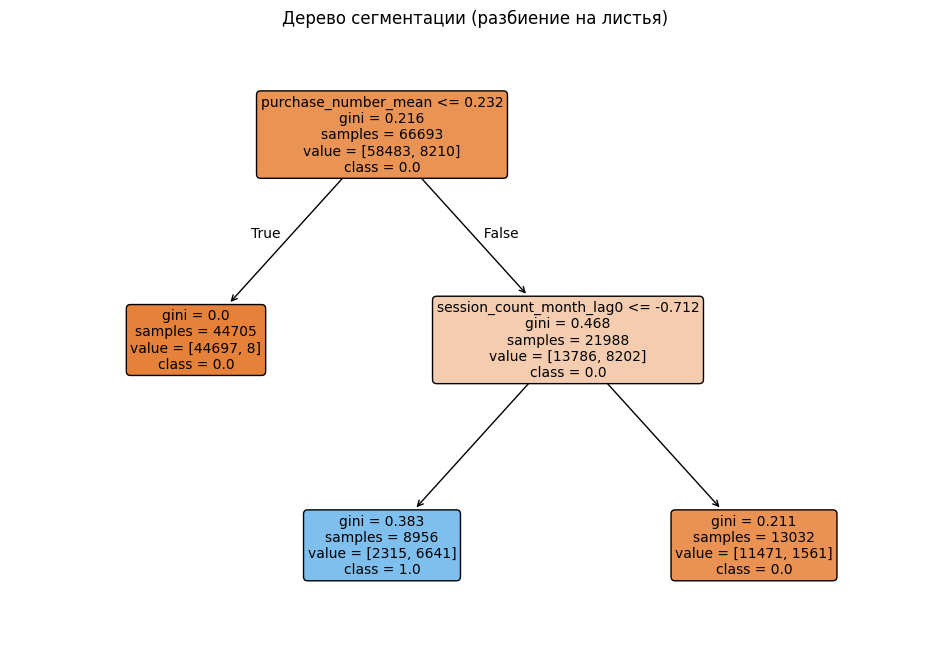

|--- purchase_number_mean <= 0.23
|   |--- class: 0.0
|--- purchase_number_mean >  0.23
|   |--- session_count_month_lag0 <= -0.71
|   |   |--- class: 1.0
|   |--- session_count_month_lag0 >  -0.71
|   |   |--- class: 0.0



In [ ]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

# Графическое представление
plt.figure(figsize=(12, 8))
plot_tree(best_model.tree_, 
          feature_names=best_model.feature_names_in_, 
          class_names=best_model.classes_.astype(str), 
          filled=True, 
          rounded=True,
          fontsize=10)
plt.title("Дерево сегментации (разбиение на листья)")
plt.show()

# Текстовое представление правил (удобно для отладки)
print(export_text(best_model.tree_, feature_names=list(best_model.feature_names_in_)))

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

base_tree = DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
model_gb = LeafModel(tree=base_tree, leaf_model=GradientBoostingClassifier(random_state=42))

grid = GridSearchCV(model_gb, param_grid={
    'leaf_model__n_estimators': [50, 100, 150], 
    'leaf_model__max_depth': [3, 5, 7], 
    'leaf_model__learning_rate': [0.01, 0.1, 0.2]
}, cv=tscv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

print(f"✅ Best Params: {grid.best_params_}")
print(f"Acc: {accuracy_score(y_test, y_pred):.4f} | Prec: {precision_score(y_test, y_pred):.4f} | Rec: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

✅ Best Params: {'leaf_model__learning_rate': 0.01, 'leaf_model__max_depth': 3, 'leaf_model__n_estimators': 100}
Acc: 0.8792 | Prec: 0.8618 | Rec: 0.8305 | F1: 0.8458 | ROC-AUC: 0.9501
              precision    recall  f1-score   support

         0.0       0.89      0.91      0.90      9287
         1.0       0.86      0.83      0.85      6171

    accuracy                           0.88     15458
   macro avg       0.88      0.87      0.87     15458
weighted avg       0.88      0.88      0.88     15458



С отбором признаков

In [20]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

base_selector = SelectKBest(score_func=f_classif)
base_tree = DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
odel_lr = LeafModel(
    tree=base_tree, 
    leaf_model=LogisticRegression(max_iter=1000, random_state=42),
    feature_selector=base_selector
)

param_grid = {
    'feature_selector__k': [5, 7, 10, 15, 20],
    'leaf_model__C': [0.01, 0.05, 0.1, 1.0, 10.0]
}

grid = GridSearchCV(odel_lr, param_grid=param_grid, cv=tscv, scoring='f1', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

y_pred = grid.predict(X_test_scaled)
y_prob = grid.predict_proba(X_test_scaled)[:, 1]

print(f"✅ Best Params: {grid.best_params_}")
print(f"Acc: {accuracy_score(y_test, y_pred):.4f} | Prec: {precision_score(y_test, y_pred):.4f} | Rec: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

✅ Best Params: {'feature_selector__k': 5, 'leaf_model__C': 0.01}
Acc: 0.8673 | Prec: 0.9073 | Rec: 0.7436 | F1: 0.8173 | ROC-AUC: 0.9426
              precision    recall  f1-score   support

         0.0       0.85      0.95      0.90      9287
         1.0       0.91      0.74      0.82      6171

    accuracy                           0.87     15458
   macro avg       0.88      0.85      0.86     15458
weighted avg       0.87      0.87      0.86     15458



In [21]:
from sklearn.ensemble import GradientBoostingClassifier

base_selector = SelectKBest(score_func=mutual_info_classif, k=5)
base_tree = DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
model_gb = LeafModel(tree=base_tree, 
                     leaf_model=GradientBoostingClassifier(random_state=42),
                     feature_selector=base_selector)

grid = GridSearchCV(model_gb, param_grid={
    'leaf_model__n_estimators': [50, 100, 150], 
    'leaf_model__max_depth': [3, 5, 7], 
    'leaf_model__learning_rate': [0.01, 0.1, 0.2]
}, cv=tscv, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

print(f"✅ Best Params: {grid.best_params_}")
print(f"Acc: {accuracy_score(y_test, y_pred):.4f} | Prec: {precision_score(y_test, y_pred):.4f} | Rec: {recall_score(y_test, y_pred):.4f} | F1: {f1_score(y_test, y_pred):.4f} | ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

✅ Best Params: {'leaf_model__learning_rate': 0.01, 'leaf_model__max_depth': 3, 'leaf_model__n_estimators': 50}
Acc: 0.8723 | Prec: 0.8202 | Rec: 0.8710 | F1: 0.8449 | ROC-AUC: 0.9446
              precision    recall  f1-score   support

         0.0       0.91      0.87      0.89      9287
         1.0       0.82      0.87      0.84      6171

    accuracy                           0.87     15458
   macro avg       0.87      0.87      0.87     15458
weighted avg       0.87      0.87      0.87     15458

